In [164]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [165]:
data = pd.read_csv('./1/2026021218.csv', index_col = 'length')
data.columns = pd.to_datetime(
    data.columns
      .str.replace("results_", "", regex=False)
      .str.replace("_dts", "", regex=False),
    format="%Y_%m_%d%H_%M_%S",
)
data.columns = data.columns.strftime("%H:%M:%S")


In [166]:
#Убираем шумную часть в отдельный датасет
times = data.columns

T = data.to_numpy()
change_per_frame = np.median(
    np.abs(np.diff(T, axis=1)), axis=0
)
median_diff = np.median(change_per_frame)
change_idx = np.flatnonzero(change_per_frame > median_diff + 0.5)[0]
change_idx

np.int64(299)

In [167]:
broken = data.iloc[:,change_idx: ]
normal = data.iloc[:,:change_idx ]

In [168]:
median_per_meter = normal.median(axis=1)
residual = normal.sub(median_per_meter, axis=0)
dt = pd.to_datetime(residual.columns, format='%H:%M:%S')

train = dt < '1900-01-01 18:15:00'
val = (dt >= '1900-01-01 18:15:00') & (dt < '1900-01-01 18:30:00')
test = dt >= '1900-01-01 18:30:00'

print(train.sum(), val.sum(), test.sum())
print(len(train), len(val), len(test))

train_data = normal.loc[:, train].copy()
val_data = normal.loc[:, val].copy()
test_data = normal.loc[:, test].copy()

90 90 119
299 299 299


<Axes: xlabel='length'>

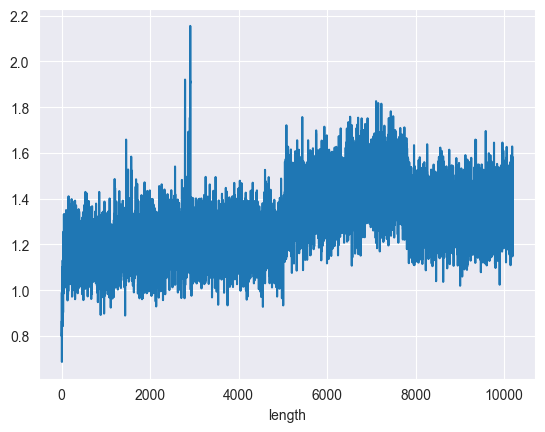

In [184]:
median_per_meter = train_data.median(axis=1)
std = train_data.std(axis=1)
train_diff = train_data.sub(median_per_meter, axis=0)
val_diff = val_data.sub(median_per_meter, axis=0)
test_diff = test_data.sub(median_per_meter, axis=0)

train_z = train_diff.div(std, axis=0)
val_z = val_diff.div(std, axis=0)
test_z = test_diff.div(std, axis=0)

sns.lineplot(std)

<Axes: ylabel='length'>

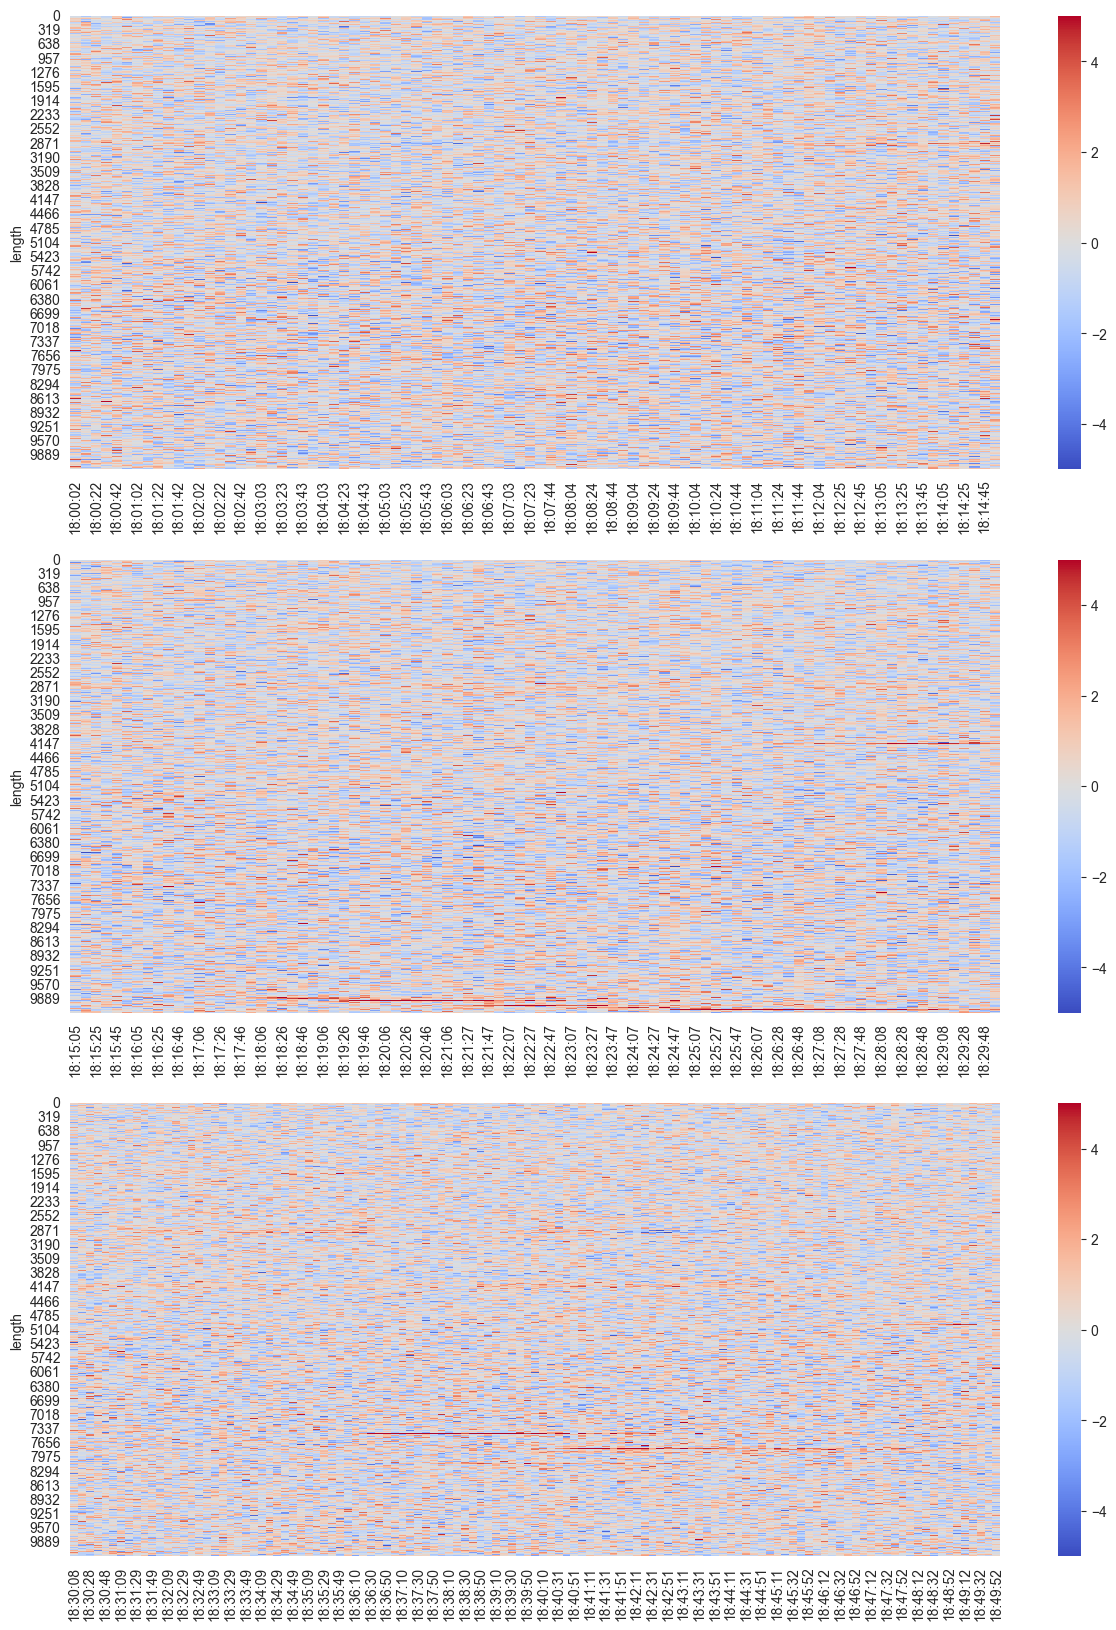

In [185]:
fig, ax = plt.subplots(3, 1, figsize=(15,20))
sns.heatmap(train_diff, cmap='coolwarm', ax=ax[0], center = 0, vmin=-5, vmax=5)
sns.heatmap(val_diff, cmap='coolwarm', ax=ax[1], center = 0, vmin=-5, vmax=5)
sns.heatmap(test_diff, cmap='coolwarm', ax=ax[2], center = 0, vmin=-5, vmax=5)

In [175]:
from scipy.ndimage import label, find_objects

low, high = -2, 2
values = val_z.to_numpy()
result = np.zeros_like(values, dtype=np.int8)
structure = np.ones((3, 3), dtype=bool)

for sign, mask in [
    (-1, values <= low),
    ( 1, values >= high),
]:
    components, _ = label(mask, structure=structure)

    for i, area in enumerate(find_objects(components), start=1):
        if area is None:
            continue

        meter_slice, time_slice = area
        n_meters = meter_slice.stop - meter_slice.start
        n_frames = time_slice.stop - time_slice.start

        # Минимум 3 метра и 6 кадров ≈ 1 минута
        if n_meters < 3 or n_frames < 6:
            continue

        local_labels = components[area]
        local_result = result[area]
        local_result[local_labels == i] = sign

result = pd.DataFrame(
    result,
    index=val_z.index,
    columns=val_z.columns,
)

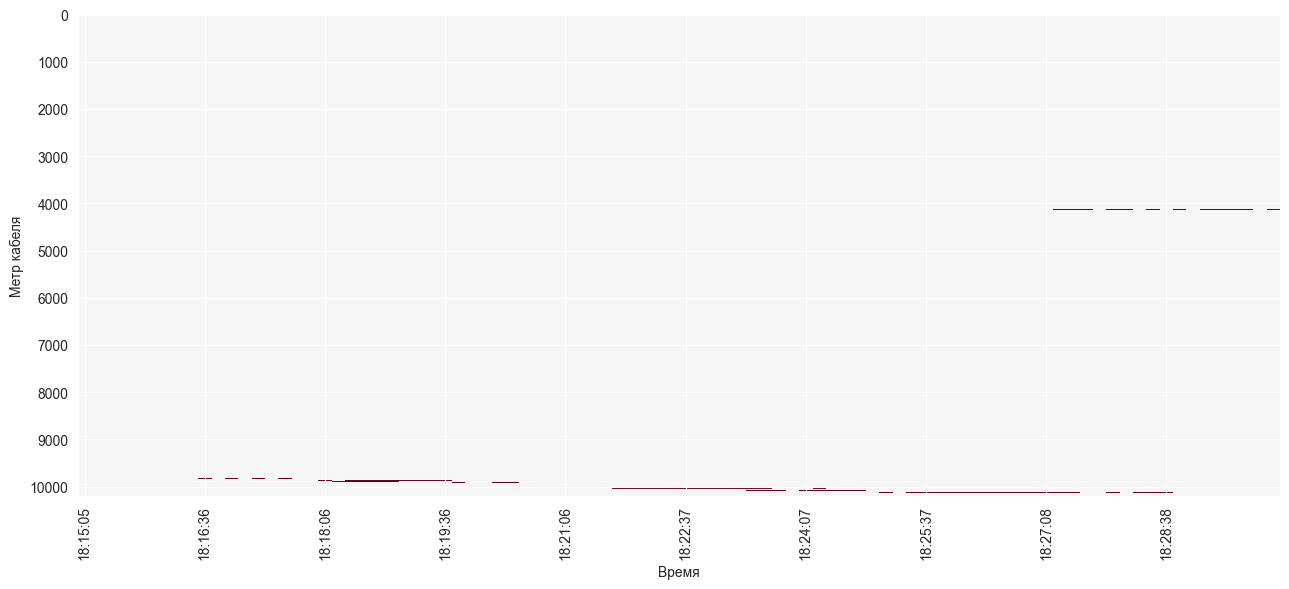

In [176]:
plt.figure(figsize=(13, 6))
plt.imshow(
    result,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
)


x_step = max(1, result.shape[1] // 10)
y_step = 1000

plt.xticks(
    np.arange(0, result.shape[1], x_step),
    result.columns[::x_step],
    rotation=90,
)
plt.yticks(
    np.arange(0, result.shape[0], y_step),
    result.index[::y_step],
)

plt.xlabel("Время")
plt.ylabel("Метр кабеля")
plt.tight_layout()
plt.show()

In [181]:
from scipy.ndimage import label, find_objects

low, high = -2, 2
values = test_z.to_numpy()
result = np.zeros_like(values, dtype=np.int8)
structure = np.ones((3, 3), dtype=bool)

for sign, mask in [
    (-1, values <= low),
    ( 1, values >= high),
]:
    components, _ = label(mask, structure=structure)

    for i, area in enumerate(find_objects(components), start=1):
        if area is None:
            continue

        meter_slice, time_slice = area
        n_meters = meter_slice.stop - meter_slice.start
        n_frames = time_slice.stop - time_slice.start

        # Минимум 3 метра и 6 кадров ≈ 1 минута
        if n_meters < 1 or n_frames < 3:
            continue

        local_labels = components[area]
        local_result = result[area]
        local_result[local_labels == i] = sign

result = pd.DataFrame(
    result,
    index=test_z.index,
    columns=test_z.columns,
)

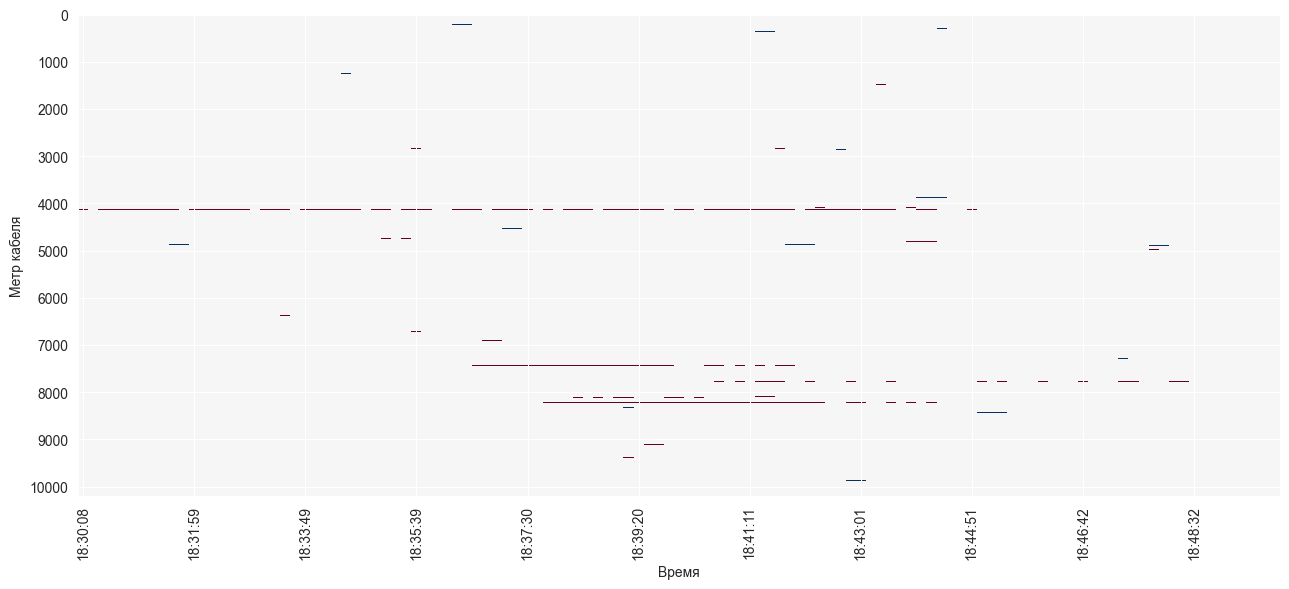

In [182]:
plt.figure(figsize=(13, 6))
plt.imshow(
    result,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
)

x_step = max(1, result.shape[1] // 10)
y_step = 1000

plt.xticks(
    np.arange(0, result.shape[1], x_step),
    result.columns[::x_step],
    rotation=90,
)
plt.yticks(
    np.arange(0, result.shape[0], y_step),
    result.index[::y_step],
)

plt.xlabel("Время")
plt.ylabel("Метр кабеля")
plt.tight_layout()
plt.show()

In [189]:
import numpy as np
import pandas as pd
from scipy.ndimage import label, find_objects


MIN_FRAMES = 6  # не менее одной минуты

# Связность только вдоль времени.
# Соседние метры пока не склеиваются.
TIME_STRUCTURE = np.array([
    [0, 0, 0],
    [1, 1, 1],
    [0, 0, 0],
], dtype=bool)


def build_temporal_mask(diff, threshold, min_frames=MIN_FRAMES):
    """
    Каждая непрерывная полоса на одном метре считается
    отдельным событием.

    -1 — охлаждение
     0 — норма
    +1 — нагрев
    """
    values = diff.to_numpy()
    result = np.zeros_like(values, dtype=np.int8)

    for sign, candidate in [
        (-1, values <= -threshold),
        (1, values >= threshold),
    ]:
        components, _ = label(
            candidate,
            structure=TIME_STRUCTURE,
        )

        component_sizes = np.bincount(components.ravel())
        keep = component_sizes >= min_frames
        keep[0] = False

        result[keep[components]] = sign

    return result


def make_event_table(diff, mask):
    records = []

    for sign, event_type in [
        (-1, "охлаждение"),
        (1, "нагрев"),
    ]:
        components, _ = label(
            mask == sign,
            structure=TIME_STRUCTURE,
        )

        for event_id, area in enumerate(
            find_objects(components), start=1
        ):
            if area is None:
                continue

            row_slice, col_slice = area
            meter_position = row_slice.start

            component = components[area] == event_id
            values = diff.to_numpy()[area][component]

            records.append({
                "тип": event_type,
                "метр": diff.index[meter_position],
                "начало": diff.columns[col_slice.start],
                "конец": diff.columns[col_slice.stop - 1],
                "длительность, с": (
                    col_slice.stop - col_slice.start
                ) * 10,
                "экстремум, °C": (
                    values.max() if sign == 1 else values.min()
                ),
            })

    return pd.DataFrame(records)

Порог: ±2 °C, минимальная длительность: 60 секунд

Train: найдено событий — 4


,№,тип,метр от,метр до,"ширина, м",начало,конец,"длительность, с","экстремум, °C",число ячеек
0,1,охлаждение,2864,2864,1,18:05:33,18:06:23,60,-3.59,6
1,2,охлаждение,2907,2907,1,18:04:33,18:05:53,90,-5.10,9
2,3,нагрев,2907,2907,1,18:13:25,18:14:25,70,5.26,7
3,4,нагрев,2909,2909,1,18:11:44,18:12:35,60,3.98,6



Validation: найдено событий — 18


,№,тип,метр от,метр до,"ширина, м",начало,конец,"длительность, с","экстремум, °C",число ячеек
0,1,нагрев,4135,4136,2,18:27:58,18:29:58,130,6.45,19
1,2,охлаждение,8263,8263,1,18:20:56,18:21:47,60,-3.71,6
2,3,нагрев,9808,9819,12,18:15:55,18:20:46,300,19.59,224
3,4,нагрев,9814,9814,1,18:21:16,18:22:27,80,3.63,8
4,5,нагрев,9823,9823,1,18:16:15,18:17:46,100,5.98,10
5,6,нагрев,9825,9827,3,18:16:15,18:18:56,170,7.93,45
6,7,нагрев,9849,9852,4,18:17:56,18:19:26,100,5.88,32
7,8,нагрев,9865,9875,11,18:17:46,18:20:56,200,14.06,156
8,9,нагрев,9884,9887,4,18:17:46,18:19:26,110,6.38,32
9,10,нагрев,9909,9909,1,18:20:26,18:21:27,70,3.09,7


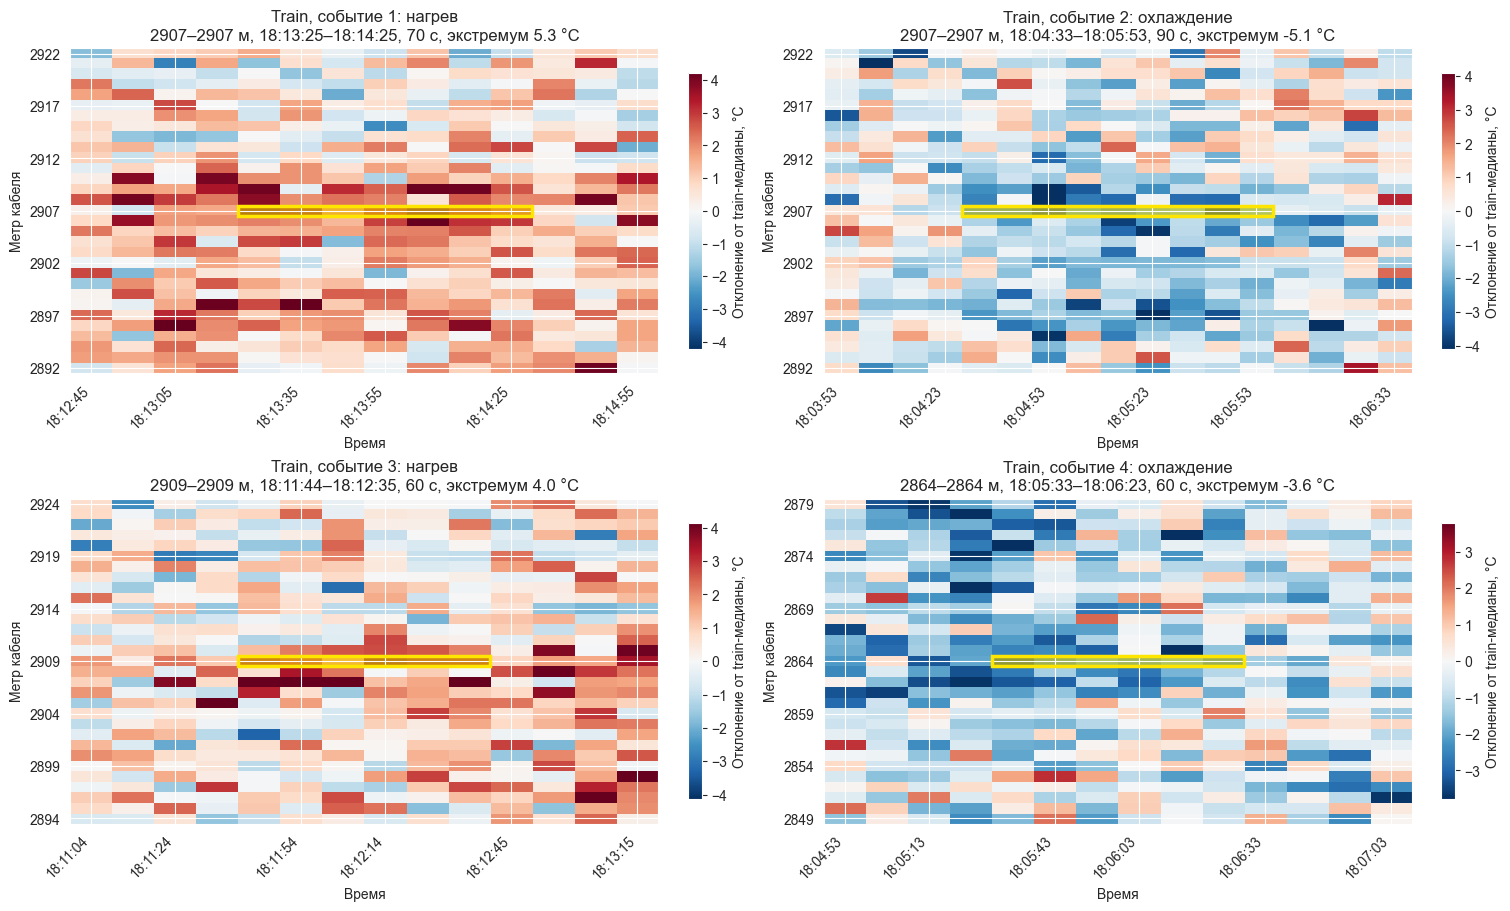

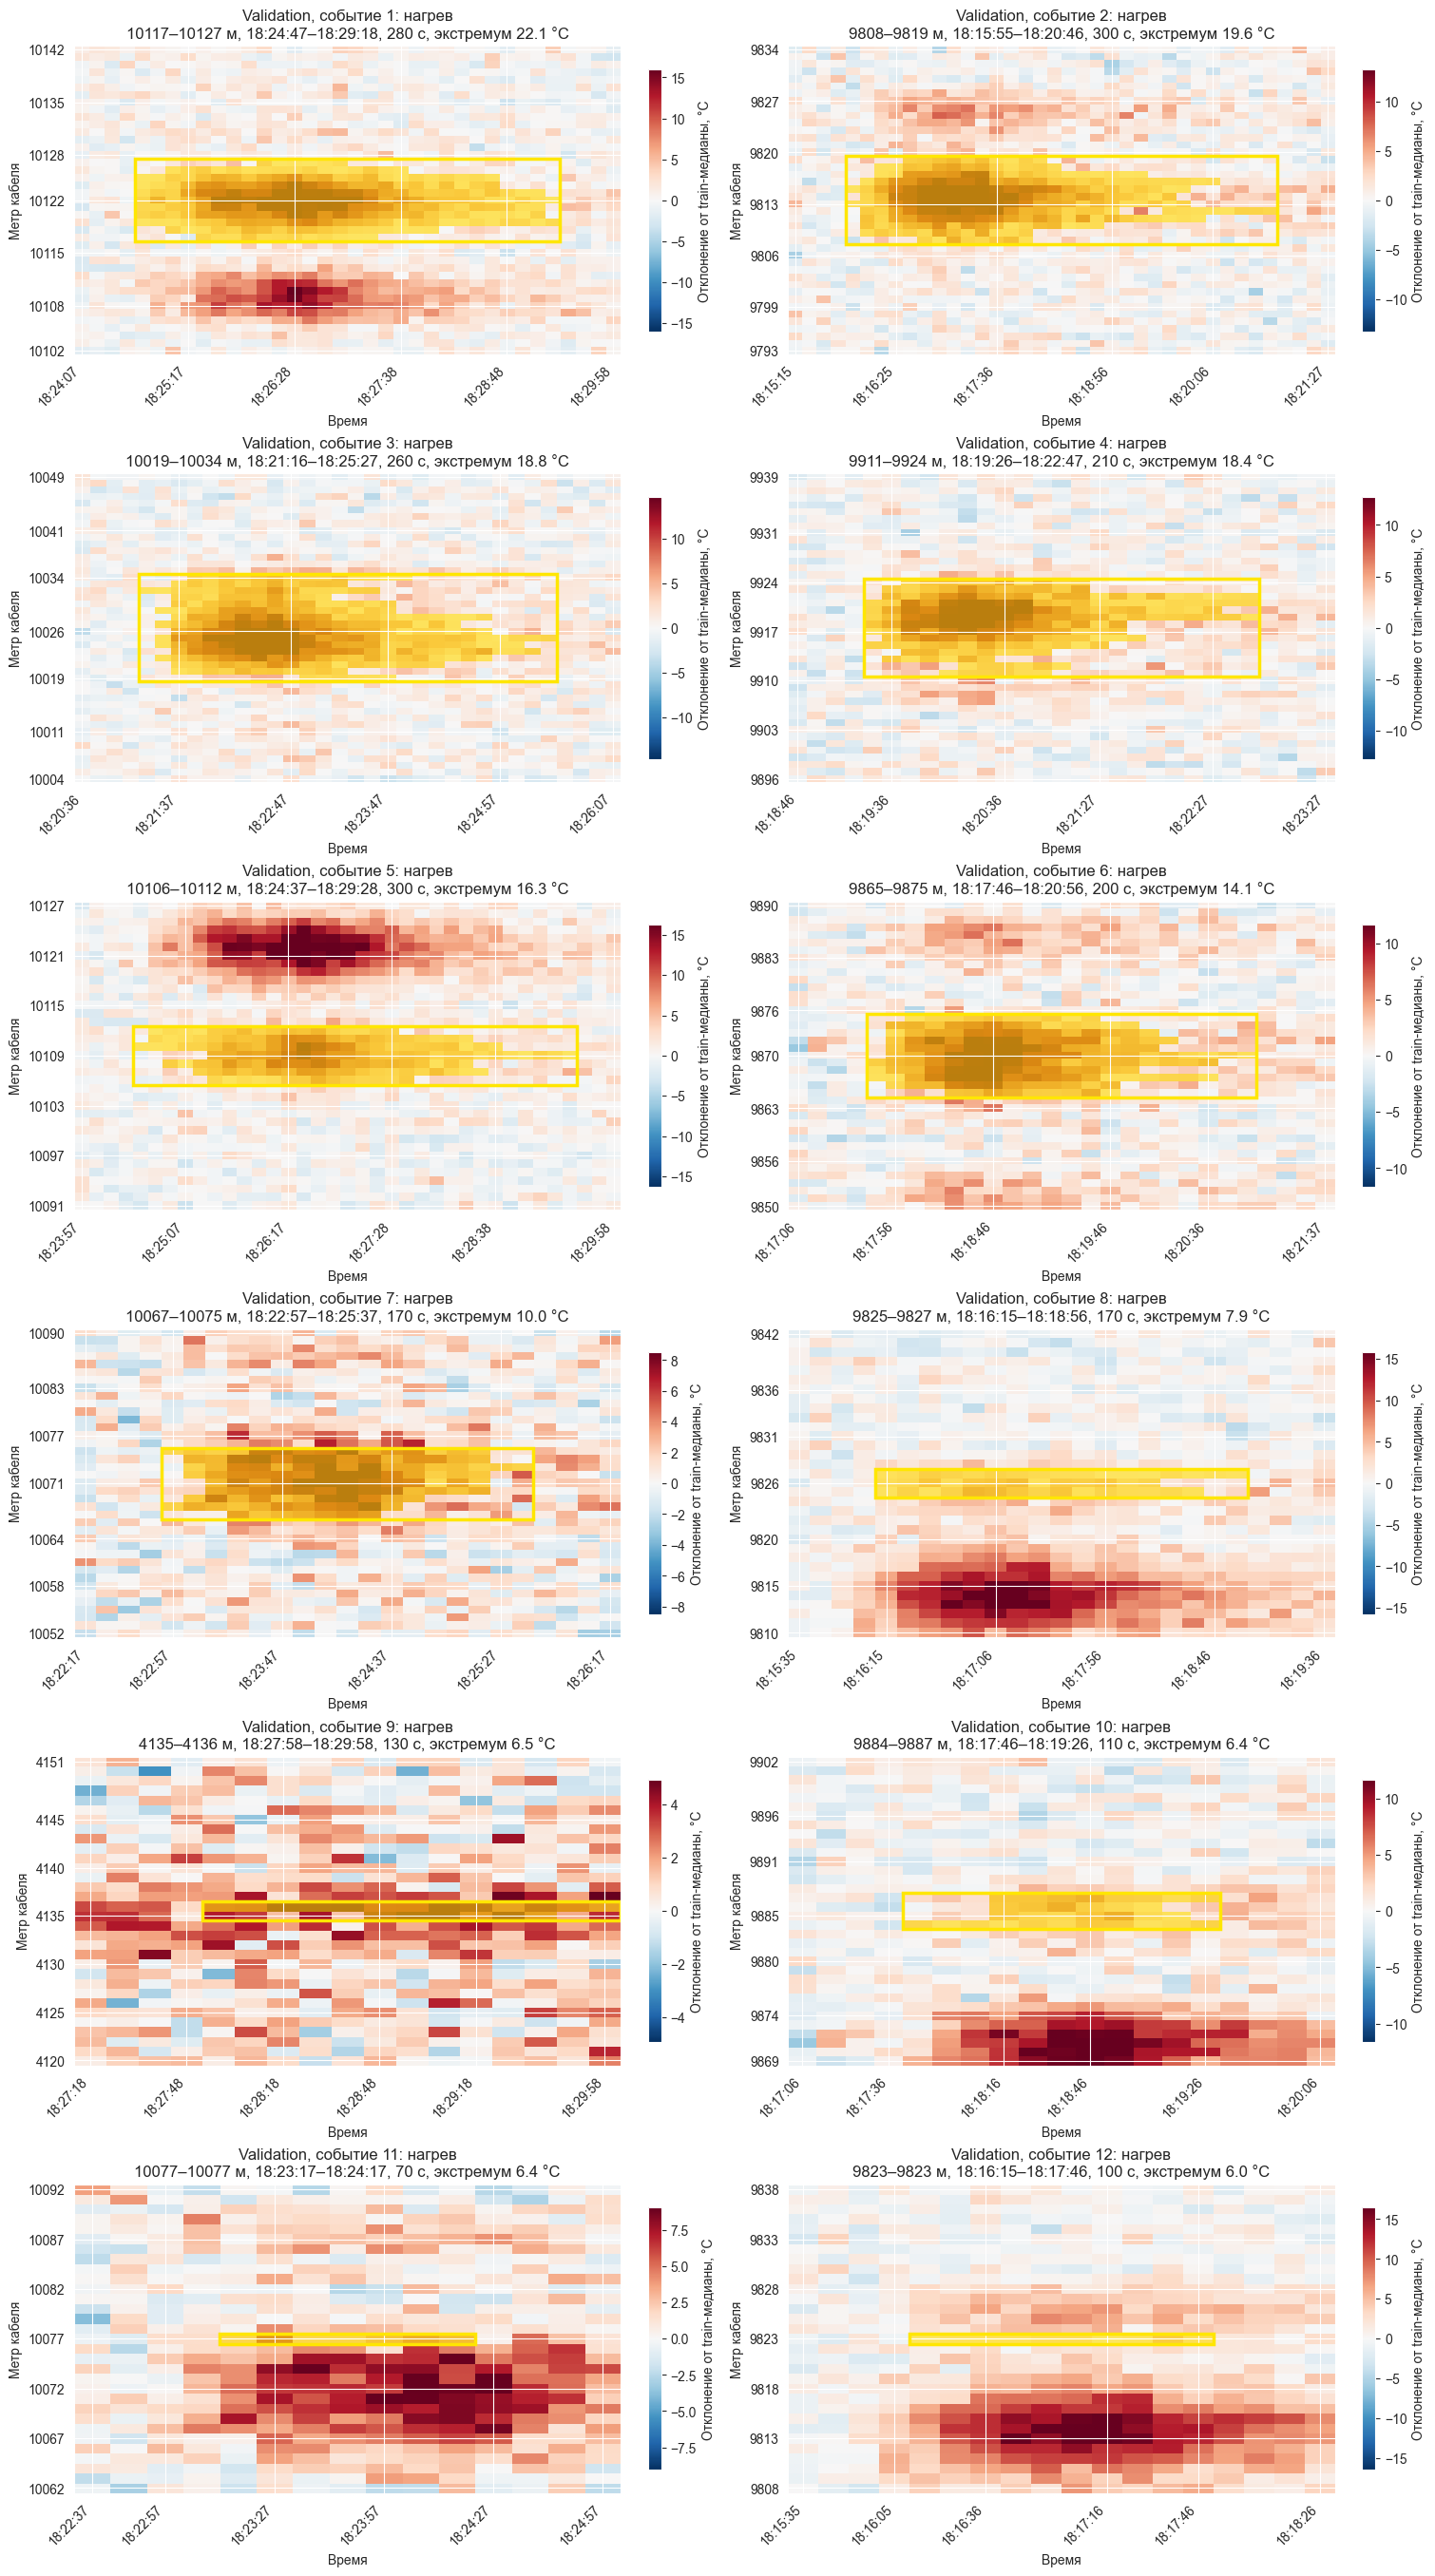

Validation: показано 12 из 18 событий


In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import ceil
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from scipy.ndimage import label, find_objects


# ============================================================
# Параметры детектора
# ============================================================

THRESHOLD = 2          # проверить также 3, 5 и 15 °C
MIN_FRAMES = 6         # 6 кадров × 10 секунд = 1 минута
FRAME_SECONDS = 10
MAX_EVENTS_TO_PLOT = 12


# Связность только вдоль времени:
# используется при удалении коротких событий
TIME_STRUCTURE = np.array([
    [0, 0, 0],
    [1, 1, 1],
    [0, 0, 0],
], dtype=bool)


# Связность по времени и непосредственно соседним метрам:
# диагональные области не склеиваются
EVENT_STRUCTURE = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
], dtype=bool)


# ============================================================
# Базовый профиль только по train
# ============================================================

train_median = train_data.median(axis=1)

train_diff = train_data.sub(train_median, axis=0)
val_diff = val_data.sub(train_median, axis=0)


# ============================================================
# Построение маски
# ============================================================

def build_temporal_mask(diff, threshold, min_frames=MIN_FRAMES):
    """
    1. Применяет порог отдельно к нагревам и охлаждениям.
    2. Рассматривает каждый метр отдельно.
    3. Удаляет непрерывные события короче min_frames.
    """
    values = diff.to_numpy()
    result = np.zeros_like(values, dtype=np.int8)

    for sign, candidate in [
        (-1, values <= -threshold),
        (1, values >= threshold),
    ]:
        components, _ = label(
            candidate,
            structure=TIME_STRUCTURE,
        )

        component_sizes = np.bincount(components.ravel())

        keep = component_sizes >= min_frames
        keep[0] = False  # фон не является событием

        result[keep[components]] = sign

    return result


# ============================================================
# Объединение соседних метров в физические события
# ============================================================

def extract_events(diff, mask):
    events = []
    diff_values = diff.to_numpy()

    for sign, event_type in [
        (-1, "охлаждение"),
        (1, "нагрев"),
    ]:
        components, _ = label(
            mask == sign,
            structure=EVENT_STRUCTURE,
        )

        for component_id, area in enumerate(
            find_objects(components),
            start=1,
        ):
            if area is None:
                continue

            row_slice, col_slice = area
            local_component = (
                components[area] == component_id
            )

            local_rows, local_cols = np.where(local_component)

            rows = local_rows + row_slice.start
            cols = local_cols + col_slice.start

            values = diff_values[rows, cols]

            events.append({
                "type": event_type,
                "sign": sign,
                "r0": rows.min(),
                "r1": rows.max() + 1,
                "c0": cols.min(),
                "c1": cols.max() + 1,
                "rows": rows,
                "cols": cols,
                "extreme": (
                    values.max()
                    if sign == 1
                    else values.min()
                ),
                "cells": len(values),
                "n_meters": len(np.unique(rows)),
            })

    return sorted(
        events,
        key=lambda event: (event["r0"], event["c0"]),
    )


# ============================================================
# Таблица событий
# ============================================================

def make_event_table(diff, events):
    columns = [
        "№",
        "тип",
        "метр от",
        "метр до",
        "ширина, м",
        "начало",
        "конец",
        "длительность, с",
        "экстремум, °C",
        "число ячеек",
    ]

    records = []

    for event_number, event in enumerate(events, start=1):
        records.append({
            "№": event_number,
            "тип": event["type"],
            "метр от": diff.index[event["r0"]],
            "метр до": diff.index[event["r1"] - 1],
            "ширина, м": event["n_meters"],
            "начало": diff.columns[event["c0"]],
            "конец": diff.columns[event["c1"] - 1],
            "длительность, с": (
                event["c1"] - event["c0"]
            ) * FRAME_SECONDS,
            "экстремум, °C": round(
                float(event["extreme"]), 2
            ),
            "число ячеек": event["cells"],
        })

    return pd.DataFrame(records, columns=columns)


# ============================================================
# Увеличенные тепловые карты событий
# ============================================================

def plot_detected_events(
    diff,
    events,
    threshold,
    title,
    max_events=MAX_EVENTS_TO_PLOT,
    padding_meters=15,
    padding_frames=4,
):
    if not events:
        print(f"{title}: события не обнаружены")
        return

    # На график сначала выводятся самые сильные события
    events_to_show = sorted(
        events,
        key=lambda event: abs(event["extreme"]),
        reverse=True,
    )

    if max_events is not None:
        events_to_show = events_to_show[:max_events]

    ncols = 2
    nrows = ceil(len(events_to_show) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4.5 * nrows),
        layout="constrained",
    )

    axes = np.atleast_1d(axes).ravel()
    yellow_cmap = ListedColormap(["#FFE600"])

    for plot_number, (ax, event) in enumerate(
        zip(axes, events_to_show),
        start=1,
    ):
        r0 = max(event["r0"] - padding_meters, 0)
        r1 = min(
            event["r1"] + padding_meters,
            diff.shape[0],
        )
        c0 = max(event["c0"] - padding_frames, 0)
        c1 = min(
            event["c1"] + padding_frames,
            diff.shape[1],
        )

        diff_zoom = diff.iloc[r0:r1, c0:c1]

        limit = max(
            threshold,
            np.nanpercentile(
                np.abs(diff_zoom.to_numpy()),
                99,
            ),
        )

        image = ax.imshow(
            diff_zoom.to_numpy(),
            cmap="RdBu_r",
            vmin=-limit,
            vmax=limit,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
        )

        # Точная маска текущего события
        local_event_mask = np.zeros(
            diff_zoom.shape,
            dtype=bool,
        )

        local_rows = event["rows"] - r0
        local_cols = event["cols"] - c0
        local_event_mask[local_rows, local_cols] = True

        overlay = np.ma.masked_where(
            ~local_event_mask,
            local_event_mask,
        )

        ax.imshow(
            overlay,
            cmap=yellow_cmap,
            alpha=0.55,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
        )

        # Граница события
        ax.add_patch(
            Rectangle(
                (
                    event["c0"] - c0 - 0.5,
                    event["r0"] - r0 - 0.5,
                ),
                event["c1"] - event["c0"],
                event["r1"] - event["r0"],
                fill=False,
                edgecolor="#FFE600",
                linewidth=2.5,
            )
        )

        x_ticks = np.linspace(
            0,
            diff_zoom.shape[1] - 1,
            min(6, diff_zoom.shape[1]),
            dtype=int,
        )
        y_ticks = np.linspace(
            0,
            diff_zoom.shape[0] - 1,
            min(7, diff_zoom.shape[0]),
            dtype=int,
        )

        ax.set_xticks(x_ticks)
        ax.set_xticklabels(
            diff_zoom.columns[x_ticks],
            rotation=45,
            ha="right",
        )

        ax.set_yticks(y_ticks)
        ax.set_yticklabels(diff_zoom.index[y_ticks])

        meter_from = diff.index[event["r0"]]
        meter_to = diff.index[event["r1"] - 1]
        start_time = diff.columns[event["c0"]]
        end_time = diff.columns[event["c1"] - 1]
        duration = (
            event["c1"] - event["c0"]
        ) * FRAME_SECONDS

        ax.set_title(
            f"{title}, событие {plot_number}: "
            f"{event['type']}\n"
            f"{meter_from}–{meter_to} м, "
            f"{start_time}–{end_time}, "
            f"{duration} с, "
            f"экстремум {event['extreme']:.1f} °C"
        )

        ax.set_xlabel("Время")
        ax.set_ylabel("Метр кабеля")

        fig.colorbar(
            image,
            ax=ax,
            label="Отклонение от train-медианы, °C",
            shrink=0.85,
        )

    for ax in axes[len(events_to_show):]:
        ax.remove()

    plt.show()

    if (
        max_events is not None
        and len(events) > max_events
    ):
        print(
            f"{title}: показано {max_events} "
            f"из {len(events)} событий"
        )


# ============================================================
# Запуск детектора
# ============================================================

train_mask = build_temporal_mask(
    train_diff,
    threshold=THRESHOLD,
)

val_mask = build_temporal_mask(
    val_diff,
    threshold=THRESHOLD,
)

train_events = extract_events(train_diff, train_mask)
val_events = extract_events(val_diff, val_mask)

train_event_table = make_event_table(
    train_diff,
    train_events,
)

val_event_table = make_event_table(
    val_diff,
    val_events,
)


print(
    f"Порог: ±{THRESHOLD} °C, "
    f"минимальная длительность: "
    f"{MIN_FRAMES * FRAME_SECONDS} секунд"
)

print(f"\nTrain: найдено событий — {len(train_events)}")
display(train_event_table)

print(f"\nValidation: найдено событий — {len(val_events)}")
display(val_event_table)


plot_detected_events(
    train_diff,
    train_events,
    threshold=THRESHOLD,
    title="Train",
)

plot_detected_events(
    val_diff,
    val_events,
    threshold=THRESHOLD,
    title="Validation",
)